# Paper figures: 4 numbered figures, 8 panels

This notebook reproduces figures for **Preserving Future Design Options in Growing Systems — The World of Warcraft: Forever Problem**, using manuscript assets in the external frozen input bundle, which predates this title change. Figures follow the archived LaTeX inclusion structure; unreferenced legacy assets are excluded from the paper's figure inventory.

Data are regenerated from frozen native response statistics, certificates, and exact constructions, then rendered as readable Matplotlib views and exported to PNG, SVG, and PDF. **Values, units, and bound directions match the paper; the layout is not a pixel-for-pixel reproduction of the original TikZ.** Original TikZ/PGFPlots sources remain in the local external input bundle; manuscript files are not included in this repository. To reproduce the exact paper layout, install TeX and run `bash build.sh` in the external staged manuscript directory.

This notebook generates no new battle observations and does not remeasure solver wall-clock times. UNKNOWN remains UNKNOWN. All writes go to the external directory specified by `WOWFS_REPRODUCTION_ROOT`. See the repository README and `docs/PAPER_MAP.md` for dependencies, input preparation, and commands to execute the full workflow.

In [1]:
from pathlib import Path
import sys

# Works from repository root or notebooks/, independent of a personal path.
repo = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "pyproject.toml").is_file() and (p / "src/wowfs").is_dir()), None)
if repo is None:
    raise RuntimeError("Start Jupyter in the repository or pass its root as the execution working directory")
if str(repo / "src") not in sys.path:
    sys.path.insert(0, str(repo / "src"))
from wowfs.reproduction.context import get_context
from wowfs.reporting.paper_assets import prepare_paper_assets
ctx = get_context()
assets = prepare_paper_assets(ctx.paper_source, ctx.output / "paper-assets", checks=True)
print("Frozen input:", ctx.paper_source)
print("Generated assets:", assets)


Frozen input: /work/Users/leiyo/wow-forever-sustainability-work/inputs/paper-reproduction/manuscript/WoW_Future_Targets_AISTATS2027
Generated assets: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928/paper-assets


In [2]:
from IPython.display import display
import matplotlib.pyplot as plt
from wowfs.reporting.paper_assets import figure_gallery
figures = {metadata[0]: (metadata, fig) for metadata, fig in figure_gallery(assets)}
# Explicit display in the matching cells below; avoid an extra global gallery.
plt.close("all")

## Figure 1 / fig:latent: same current performance, different future completability

This is an exact theoretical construction, not a native game experiment. Both first choices have current response (1.02, 1); the only above-cap pair is (b,t). The curves use the original figure's formulas and five example targets exactly. Sources: `sections/figure_theory.tex`, `theory/src/completion.py::latent_repair_instance`.

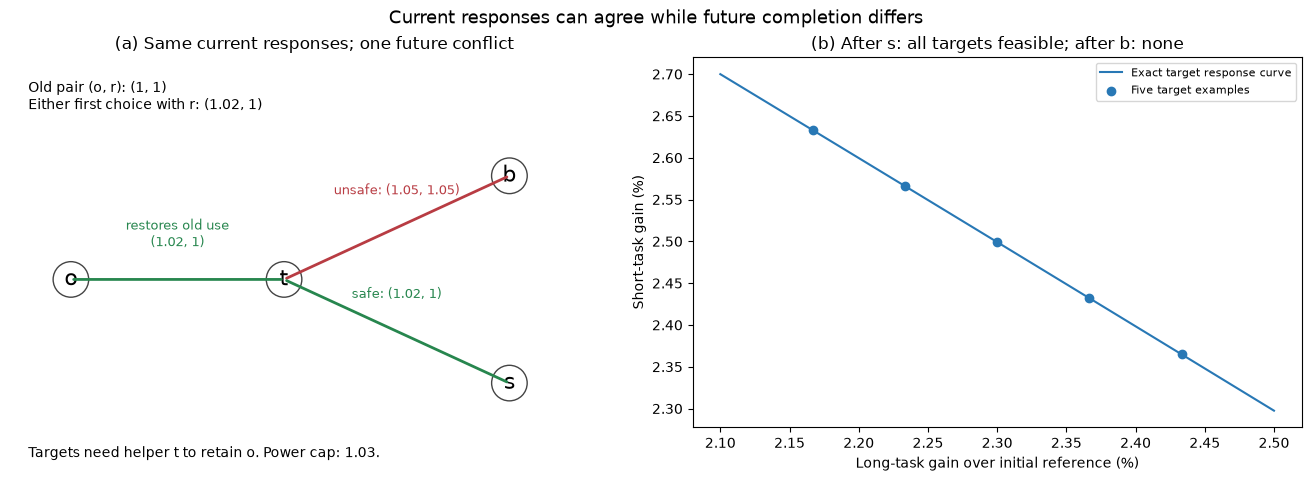

In [3]:
display(figures['fig:latent'][1])

## Figure 2 / fig:triple: Druid pairwise YES / triple NO

A = Shivery Handwraps, B = Mooncloth Boots, C = Premier Knight-Champion's Lunarhide Boots. Every target pair admits a completion; all 128 publication supersets containing the triple are excluded; all 32 physical configurations are power-safe. The right panel shows retention **upper bounds** after allowing all remaining repairs, with arrows pointing toward −∞. The targets are post hoc queries within the original simultaneous event, not new independent samples. Sources: `TRIPLE_SOURCE_CERTIFICATE_v2.json`, `TRIPLE_INDEPENDENT_CERTIFICATES.json`.

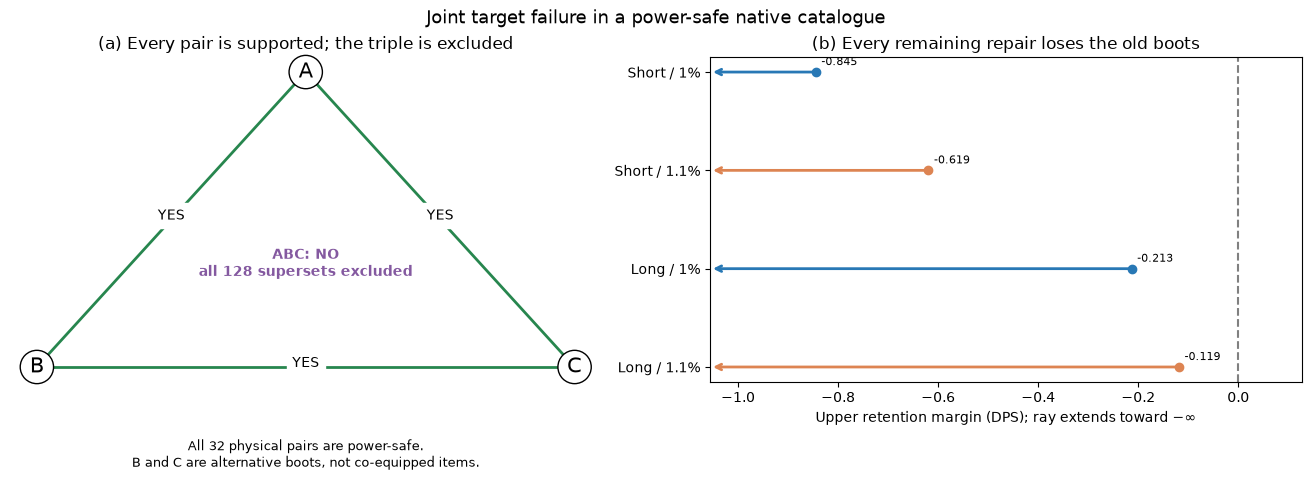

In [4]:
display(figures['fig:triple'][1])

## Figure 3 / fig:tolerance: tolerance and source obligations

Each of the four tolerances includes all 128 targets. Source-group categories may overlap; retaining only a group and removing a group answer different questions. The values 42, 39, 28, and 16 are read directly from the original JSON rather than entered by hand. Source: `evidence/v2/native-summary/NATIVE_EVIDENCE_SUMMARY.json`.

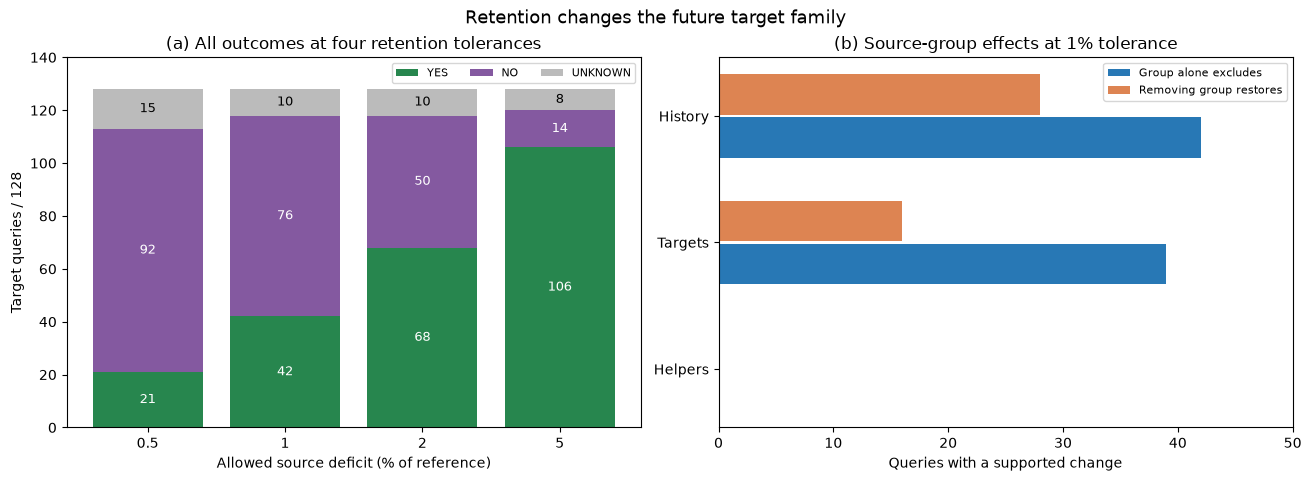

In [5]:
display(figures['fig:tolerance'][1])

## Figure 4 / fig:exclusion: certificates excluding every repair batch

The supplementary trinket certificate shows cap-margin **intervals** for retained Second Wind with alternative off-hands on the left, and retention **upper bounds** for Eye of the Beast on the right. Negative upper bounds support exclusion; the rays do not represent two-sided intervals. Source: `NATIVE_ALL_WIDTH_CERTIFICATES.json`, recomputed from `theory/data/TRINKET_MOMENTS.npz`.

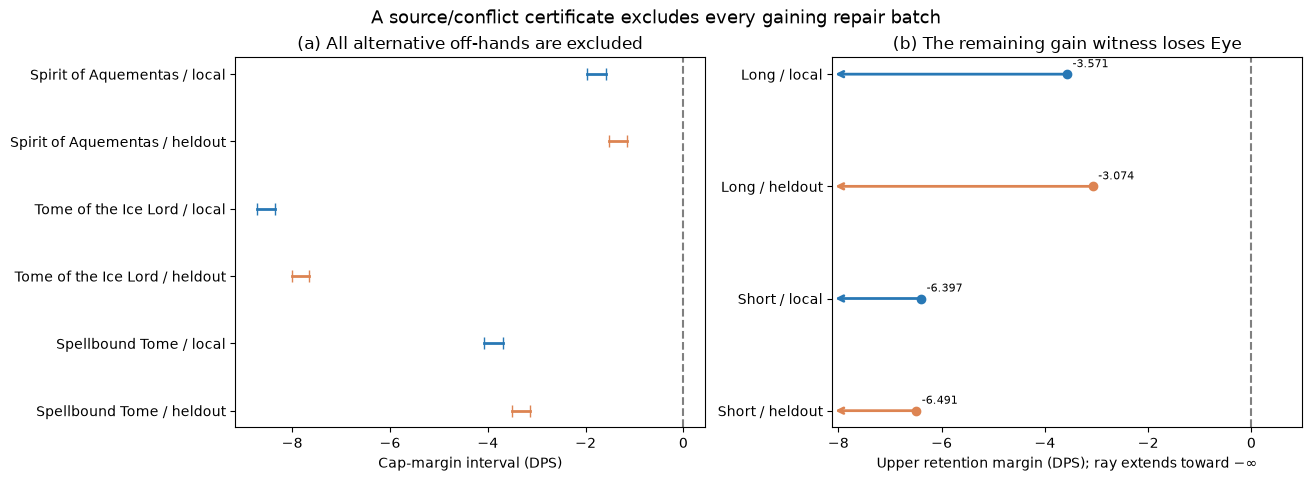

In [6]:
display(figures['fig:exclusion'][1])

## Outputs and provenance

`PAPER_ASSETS.json` records SHA-256 hashes of inputs and maintained sources, the commands actually executed, and check results. Existing PDFs in the directory belong to the frozen inputs; figures newly rendered by this notebook are in `notebook-figures/`.

In [7]:
import json
receipt = json.loads((assets / "PAPER_ASSETS.json").read_text())
display({key: receipt[key] for key in ("status", "numerical_replay", "new_native_battles", "new_timing_runs", "exact_tex_build")})
print("New figures:", assets / "notebook-figures")
print("Original TeX sources staged for optional build:", assets / "manuscript/figures")

{'status': 'PASS',
 'numerical_replay': 'PASS',
 'new_native_battles': 0,
 'new_timing_runs': 0,
 'exact_tex_build': 'not_run'}

New figures: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928/paper-assets/notebook-figures
Original TeX sources staged for optional build: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928/paper-assets/manuscript/figures
